# Reconhecimento de Dígitos Manuscritos com Redes Neurais
### Disciplina: Inteligência Artificial — Graduação em Ciência da Computação

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:
- Compreender o dataset **MNIST** e sua importância histórica em IA
- Construir e treinar uma **rede neural densa** para classificação de imagens
- Construir e treinar uma **Rede Neural Convolucional (CNN)**
- Comparar o desempenho das duas abordagens
- Interpretar métricas de avaliação: acurácia, matriz de confusão e relatório de classificação

---

## 1. Contexto e Motivação

O **MNIST** (*Modified National Institute of Standards and Technology*) é um dos datasets mais famosos da história do aprendizado de máquina. Foi criado por Yann LeCun, Corinna Cortes e Christopher Burges na década de 1990 e contém:

- **70.000 imagens** de dígitos manuscritos (0 a 9)
- Cada imagem tem **28×28 pixels** em escala de cinza
- **60.000 imagens** para treino e **10.000** para teste

Este problema é um clássico de **classificação multiclasse** com 10 classes (uma para cada dígito).

```
Entrada: imagem 28×28 pixels  →  Modelo  →  Saída: dígito (0–9)
```

> **Por que MNIST?** É simples o suficiente para ser resolvido rapidamente, mas complexo o suficiente para ilustrar conceitos fundamentais de deep learning.

## 2. Configuração do Ambiente

Vamos importar todas as bibliotecas necessárias. No Google Colab, todas já estão instaladas.

| Biblioteca | Uso |
|---|---|
| `tensorflow` / `keras` | Construção e treino das redes neurais |
| `numpy` | Manipulação de arrays numéricos |
| `matplotlib` | Visualização de dados e resultados |
| `sklearn` | Métricas de avaliação |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix, classification_report

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow versão: {tf.__version__}')
print(f'GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow versão: 2.20.0
GPU disponível: True


## 3. Carregando e Explorando o Dataset

O Keras já inclui o MNIST embutido. Vamos carregá-lo e entender sua estrutura.

In [ ]:
# Carrega os dados já divididos em treino e teste
(X_treino, y_treino), (X_teste, y_teste) = mnist.load_data()

print('=== Formato dos dados ===')
print(f'X_treino: {X_treino.shape}  →  {X_treino.shape[0]} imagens de {X_treino.shape[1]}×{X_treino.shape[2]} pixels')
print(f'y_treino: {y_treino.shape}  →  {X_treino.shape[0]} rótulos')
print(f'X_teste:  {X_teste.shape}   →  {X_teste.shape[0]} imagens de {X_teste.shape[1]}×{X_teste.shape[2]} pixels')
print(f'y_teste:  {y_teste.shape}   →  {X_teste.shape[0]} rótulos')
print()
print(f'Tipo dos pixels: {X_treino.dtype}')
print(f'Valor mínimo: {X_treino.min()}  |  Valor máximo: {X_treino.max()}')
print(f'Classes disponíveis: {np.unique(y_treino)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Formato dos dados ===
X_treino: (60000, 28, 28)  →  60000 imagens de 28×28 pixels
y_treino: (60000,)  →  60000 rótulos
X_teste:  (10000, 28, 28)   →  10000 imagens de 28×28 pixels
y_teste:  (10000,)   →  10000 rótulos

Tipo dos pixels: uint8
Valor mínimo: 0  |  Valor máximo: 255
Classes disponíveis: [0 1 2 3 4 5 6 7 8 9]


### 3.1 Visualizando Exemplos do Dataset

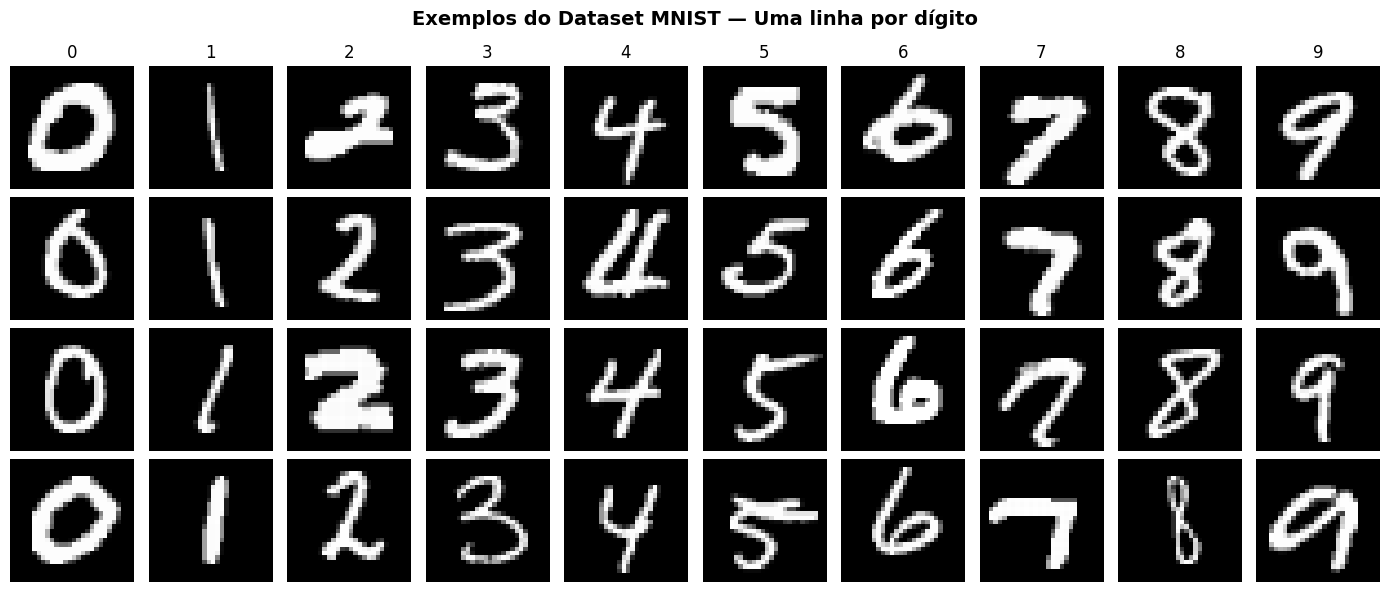

In [ ]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle('Exemplos do Dataset MNIST — Uma linha por dígito', fontsize=14, fontweight='bold')

for digito in range(10):
    # Pega os índices onde y == dígito
    indices = np.where(y_treino == digito)[0]
    amostras = np.random.choice(indices, 4, replace=False)
    for linha, idx in enumerate(amostras):
        ax = axes[linha, digito]
        ax.imshow(X_treino[idx], cmap='gray')
        ax.axis('off')
        if linha == 0:
            ax.set_title(str(digito), fontsize=12)

plt.tight_layout()
plt.show()

### 3.2 Distribuição das Classes

Em classificação, é importante verificar se as classes estão **balanceadas** — ou seja, se existem quantidades similares de exemplos de cada classe.

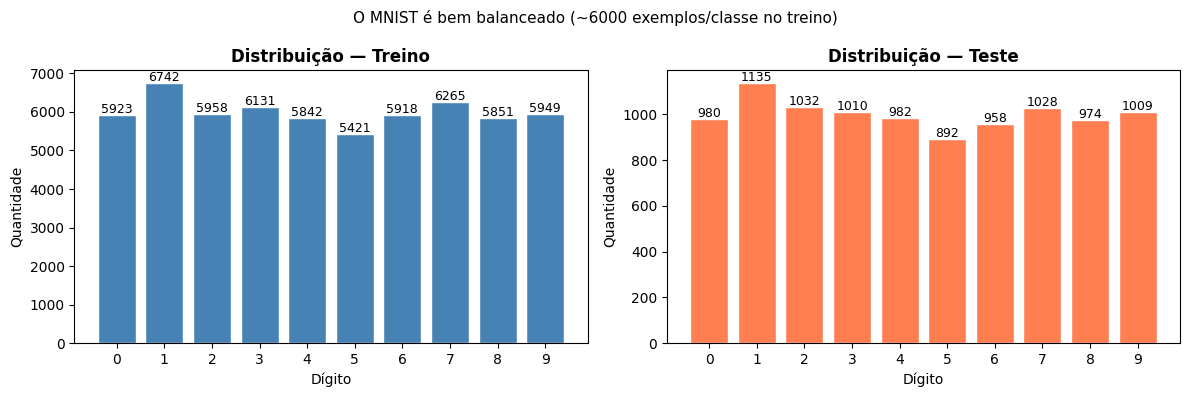

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

contagens_treino = np.bincount(y_treino)
contagens_teste  = np.bincount(y_teste)

ax1.bar(range(10), contagens_treino, color='steelblue', edgecolor='white')
ax1.set_title('Distribuição — Treino', fontweight='bold')
ax1.set_xlabel('Dígito'); ax1.set_ylabel('Quantidade')
ax1.set_xticks(range(10))
for i, v in enumerate(contagens_treino):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=9)

ax2.bar(range(10), contagens_teste, color='coral', edgecolor='white')
ax2.set_title('Distribuição — Teste', fontweight='bold')
ax2.set_xlabel('Dígito'); ax2.set_ylabel('Quantidade')
ax2.set_xticks(range(10))
for i, v in enumerate(contagens_teste):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.suptitle('O MNIST é bem balanceado (~6000 exemplos/classe no treino)', fontsize=11)
plt.tight_layout()
plt.show()

### 3.3 Visualizando um Pixel como Dado Numérico

É importante entender que uma imagem **é apenas uma matriz de números**.

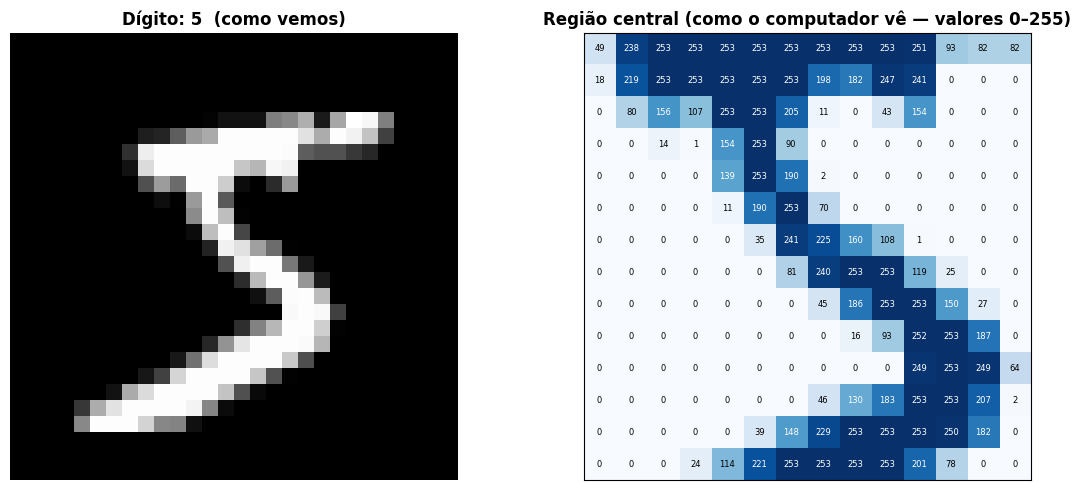

Formato da imagem: (28, 28) = 784 valores numéricos


In [ ]:
idx = 0  # Índice do exemplo
imagem = X_treino[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(imagem, cmap='gray')
ax1.set_title(f'Dígito: {y_treino[idx]}  (como vemos)', fontweight='bold')
ax1.axis('off')

# Mostra a região central da matriz (14×14) com valores
recorte = imagem[7:21, 7:21]
im = ax2.imshow(recorte, cmap='Blues')
ax2.set_title('Região central (como o computador vê — valores 0–255)', fontweight='bold')
for i in range(recorte.shape[0]):
    for j in range(recorte.shape[1]):
        valor = recorte[i, j]
        cor = 'white' if valor > 128 else 'black'
        ax2.text(j, i, str(valor), ha='center', va='center', fontsize=6, color=cor)
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.show()
print(f'Formato da imagem: {imagem.shape} = {imagem.shape[0]*imagem.shape[1]} valores numéricos')

## 4. Pré-processamento dos Dados

Antes de alimentar os dados à rede neural, precisamos fazer dois passos essenciais:

### 4.1 Normalização
Os pixels têm valores entre **0 e 255**. Dividimos por 255 para colocá-los no intervalo **[0, 1]**.

> **Por quê?** Redes neurais treinam muito melhor com valores pequenos e próximos. Entradas muito grandes causam gradientes instáveis.

### 4.2 Reshape
- Para a **rede densa**: a imagem 28×28 vira um vetor de 784 valores
- Para a **CNN**: a imagem 28×28 ganha um canal extra → 28×28×1

In [ ]:
# Normalização: [0, 255] → [0.0, 1.0]
X_treino_norm = X_treino.astype('float32') / 255.0
X_teste_norm  = X_teste.astype('float32')  / 255.0

# Para rede densa: achata 28×28 em 784
X_treino_flat = X_treino_norm.reshape(-1, 784)
X_teste_flat  = X_teste_norm.reshape(-1, 784)

# Para CNN: adiciona dimensão de canal (28, 28) → (28, 28, 1)
X_treino_cnn = X_treino_norm[..., np.newaxis]
X_teste_cnn  = X_teste_norm[..., np.newaxis]

print('=== Dados pré-processados ===')
print(f'Rede densa  — X_treino_flat: {X_treino_flat.shape}')
print(f'CNN         — X_treino_cnn:  {X_treino_cnn.shape}')
print(f'Intervalo após normalização: [{X_treino_norm.min():.1f}, {X_treino_norm.max():.1f}]')

=== Dados pré-processados ===
Rede densa  — X_treino_flat: (60000, 784)
CNN         — X_treino_cnn:  (60000, 28, 28, 1)
Intervalo após normalização: [0.0, 1.0]


## 5. Modelo 1 — Rede Neural Densa (MLP)

### Como funciona?

Uma **rede neural densa** (ou *Multilayer Perceptron* — MLP) conecta cada neurônio de uma camada a **todos** os neurônios da camada seguinte.

```
Entrada (784)  →  Camada Oculta 1 (256 neurônios, ReLU)
               →  Camada Oculta 2 (128 neurônios, ReLU)
               →  Saída (10 neurônios, Softmax)
```

A função de ativação **Softmax** na saída transforma os valores em **probabilidades** que somam 1.

### Dropout
Durante o treino, o **Dropout** desativa aleatoriamente uma fração dos neurônios. Isso previne **overfitting** (memorização dos dados de treino).

In [ ]:
def criar_mlp():
    modelo = keras.Sequential([
        # Entrada: vetor de 784 valores
        layers.Input(shape=(784,)),

        # Camada oculta 1
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        # Camada oculta 2
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),

        # Saída: 10 classes com probabilidades
        layers.Dense(10, activation='softmax'),
    ], name='MLP')
    return modelo

mlp = criar_mlp()
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping: para o treino se a validação não melhorar
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

print('Iniciando treino do MLP...')
historico_mlp = mlp.fit(
    X_treino_flat, y_treino,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Iniciando treino do MLP...
Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8843 - loss: 0.3879 - val_accuracy: 0.9652 - val_loss: 0.1164
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9508 - loss: 0.1650 - val_accuracy: 0.9740 - val_loss: 0.0859
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9631 - loss: 0.1230 - val_accuracy: 0.9768 - val_loss: 0.0759
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9679 - loss: 0.1024 - val_accuracy: 0.9792 - val_loss: 0.0704
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.0856 - val_accuracy: 0.9802 - val_loss: 0.0693
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0753 - val_accuracy: 0.9817 - val_loss: 0.0628
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.0654 - val_accuracy: 0.9833 - val_loss: 0.0606
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9802 - loss

## 6. Modelo 2 — Rede Neural Convolucional (CNN)

### Por que usar CNN para imagens?

A MLP trata cada pixel de forma **independente**, ignorando a estrutura espacial da imagem. A CNN, por outro lado, usa **filtros convolucionais** que aprendem padrões locais (bordas, curvas, texturas) preservando a estrutura 2D.

```
Entrada (28×28×1)
  → Conv2D (32 filtros 3×3, ReLU)  →  detecta bordas/texturas simples
  → MaxPooling (2×2)               →  reduz dimensionalidade (14×14)
  → Conv2D (64 filtros 3×3, ReLU)  →  detecta padrões mais complexos
  → MaxPooling (2×2)               →  reduz para 7×7
  → Flatten                        →  achata para vetor
  → Dense (128, ReLU)
  → Saída (10, Softmax)
```

> **MaxPooling** seleciona o maior valor em janelas de 2×2, reduzindo o tamanho e tornando o modelo mais robusto a pequenas variações de posição.

In [ ]:
def criar_cnn():
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Bloco convolucional 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Bloco convolucional 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Classificador
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ], name='CNN')
    return modelo

cnn = criar_cnn()
cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_cnn = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

print('Iniciando treino da CNN...')
historico_cnn = cnn.fit(
    X_treino_cnn, y_treino,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop_cnn],
    verbose=1
)

Iniciando treino da CNN...
Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9244 - loss: 0.2502 - val_accuracy: 0.9825 - val_loss: 0.0602
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9786 - loss: 0.0708 - val_accuracy: 0.9880 - val_loss: 0.0459
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9840 - loss: 0.0513 - val_accuracy: 0.9912 - val_loss: 0.0349
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0398 - val_accuracy: 0.9922 - val_loss: 0.0348
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9900 - loss: 0.0318 - val_accuracy: 0.9903 - val_loss: 0.0362
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0279 - val_accuracy: 0.9905 - val_loss: 0.0343
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9925 - val_loss: 0.0312
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9936 - lo

## 7. Comparando as Curvas de Aprendizado

As curvas de aprendizado mostram como a **perda** e a **acurácia** evoluem a cada época, tanto no treino quanto na validação.

- **Overfitting**: acurácia de treino cresce mas a de validação estagna ou cai
- **Underfitting**: ambas as acurácias são baixas
- **Bom ajuste**: treino e validação próximos e com acurácia alta

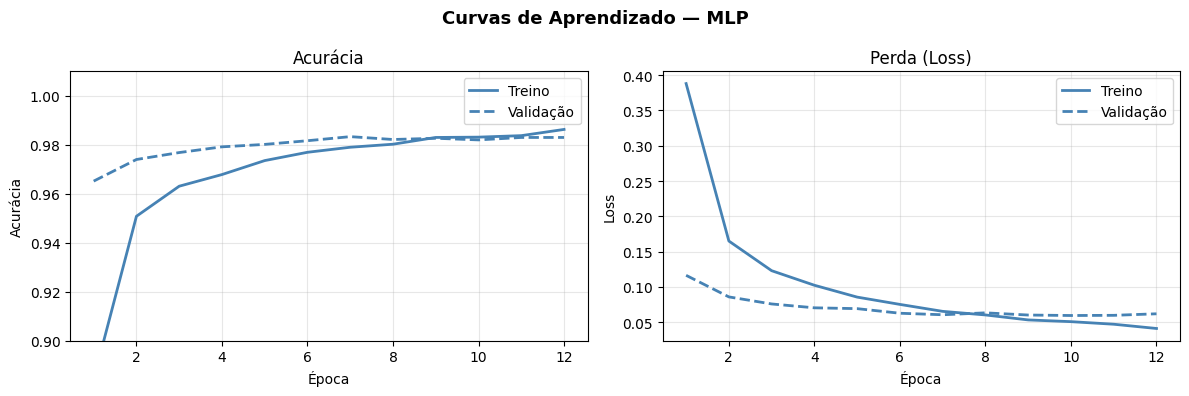

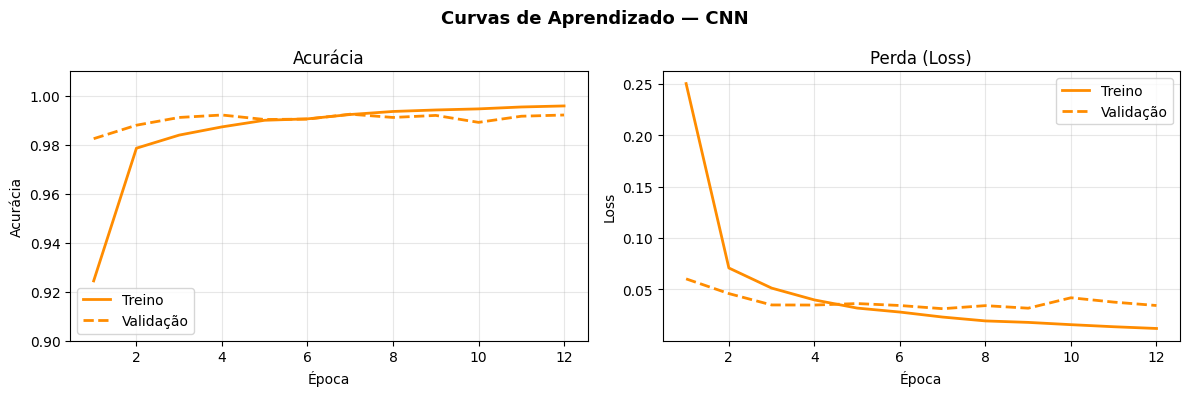

In [ ]:
def plotar_historico(historico, titulo, cor):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    epocas = range(1, len(historico.history['accuracy']) + 1)

    ax1.plot(epocas, historico.history['accuracy'],     color=cor,   label='Treino',    linewidth=2)
    ax1.plot(epocas, historico.history['val_accuracy'], color=cor,   label='Validação', linewidth=2, linestyle='--')
    ax1.set_title('Acurácia'); ax1.set_xlabel('Época'); ax1.set_ylabel('Acurácia')
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0.9, 1.01])

    ax2.plot(epocas, historico.history['loss'],     color=cor,   label='Treino',    linewidth=2)
    ax2.plot(epocas, historico.history['val_loss'], color=cor,   label='Validação', linewidth=2, linestyle='--')
    ax2.set_title('Perda (Loss)'); ax2.set_xlabel('Época'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plotar_historico(historico_mlp, 'Curvas de Aprendizado — MLP', 'steelblue')
plotar_historico(historico_cnn, 'Curvas de Aprendizado — CNN', 'darkorange')

## 8. Avaliação no Conjunto de Teste

> **Atenção**: o conjunto de teste só deve ser usado **uma vez**, após o treino concluído. Usá-lo durante o desenvolvimento causa *data leakage* — o modelo vira otimizado para o teste, não para dados novos.

In [ ]:
loss_mlp, acc_mlp = mlp.evaluate(X_teste_flat, y_teste, verbose=0)
loss_cnn, acc_cnn = cnn.evaluate(X_teste_cnn,  y_teste, verbose=0)

print('=' * 45)
print(f'{'Modelo':<10}  {'Acurácia':>10}  {'Erro (Loss)':>12}')
print('-' * 45)
print(f'{'MLP':<10}  {acc_mlp:>10.4f}  {loss_mlp:>12.4f}')
print(f'{'CNN':<10}  {acc_cnn:>10.4f}  {loss_cnn:>12.4f}')
print('=' * 45)
print(f'\nA CNN supera a MLP em {(acc_cnn - acc_mlp)*100:.2f} pontos percentuais')

Modelo        Acurácia   Erro (Loss)
---------------------------------------------
MLP             0.9810        0.0665
CNN             0.9924        0.0244

A CNN supera a MLP em 1.14 pontos percentuais


### 8.1 Matriz de Confusão

A **matriz de confusão** mostra, para cada classe verdadeira, quantas vezes o modelo previu cada classe. A diagonal principal representa acertos.

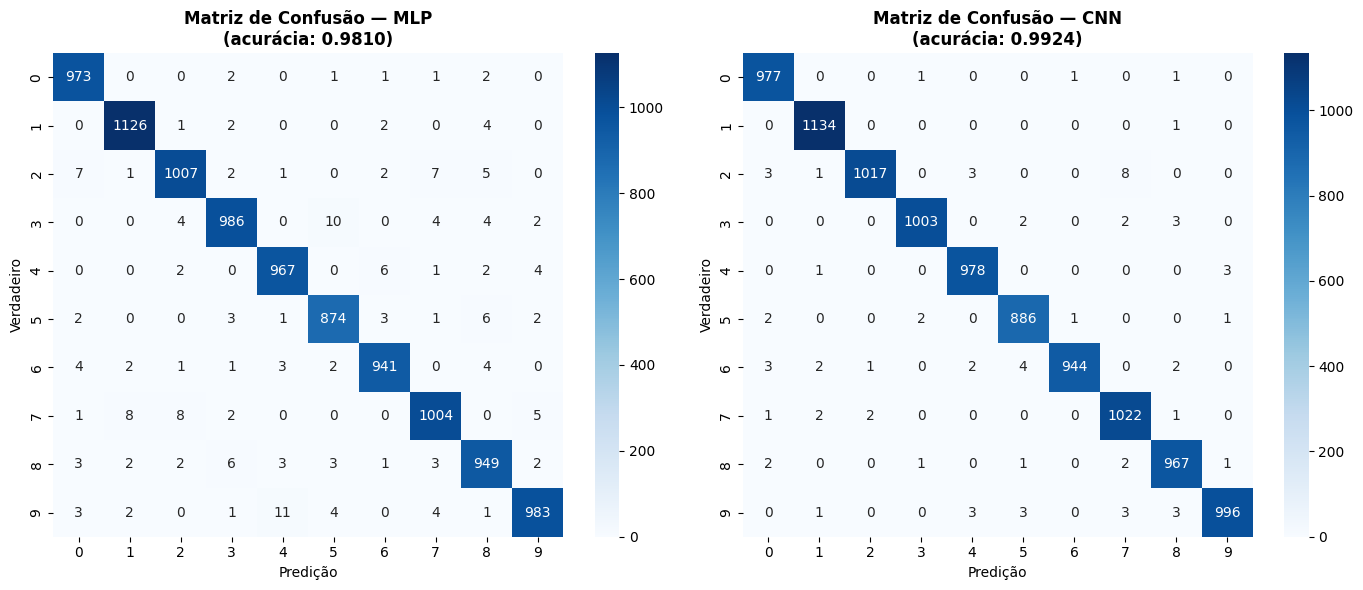

In [ ]:
y_pred_mlp = np.argmax(mlp.predict(X_teste_flat, verbose=0), axis=1)
y_pred_cnn = np.argmax(cnn.predict(X_teste_cnn,  verbose=0), axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, titulo in [
    (ax1, y_pred_mlp, f'Matriz de Confusão — MLP\n(acurácia: {acc_mlp:.4f})'),
    (ax2, y_pred_cnn, f'Matriz de Confusão — CNN\n(acurácia: {acc_cnn:.4f})'),
]:
    cm = confusion_matrix(y_teste, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=range(10), yticklabels=range(10)
    )
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Predição'); ax.set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()

### 8.2 Relatório de Classificação

O relatório mostra **precisão**, **recall** e **F1-score** para cada classe:

| Métrica | Definição |
|---|---|
| **Precisão** | De tudo que o modelo disse ser classe X, quantos % eram realmente X? |
| **Recall** | De todos os exemplos reais da classe X, quantos % o modelo acertou? |
| **F1-score** | Média harmônica de precisão e recall |

In [ ]:
print('=== Relatório de Classificação — CNN ===')
print(classification_report(y_teste, y_pred_cnn, target_names=[str(i) for i in range(10)]))

=== Relatório de Classificação — CNN ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### 8.3 Analisando os Erros

Vamos ver exemplos onde a CNN errou — isso nos ajuda a entender as limitações do modelo.

Total de erros da CNN: 76 de 10000 (0.76%)


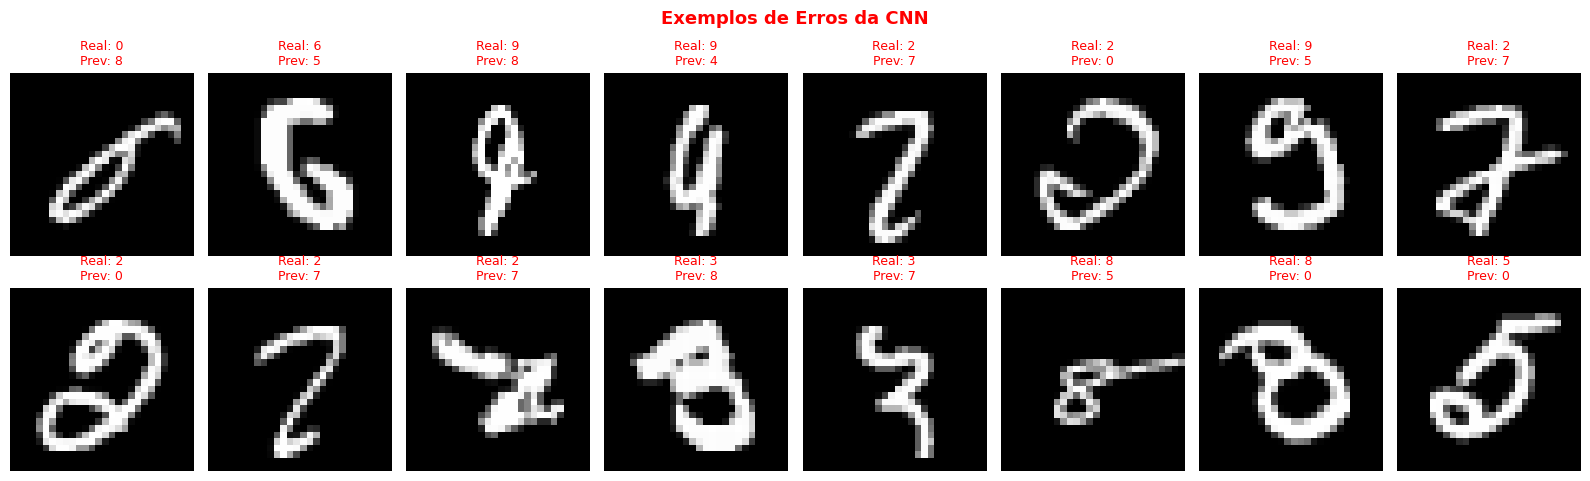

In [ ]:
erros = np.where(y_pred_cnn != y_teste)[0]
print(f'Total de erros da CNN: {len(erros)} de {len(y_teste)} ({len(erros)/len(y_teste)*100:.2f}%)')

amostras_erro = np.random.choice(erros, min(16, len(erros)), replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Exemplos de Erros da CNN', fontsize=13, fontweight='bold', color='red')

for ax, idx in zip(axes.flatten(), amostras_erro):
    ax.imshow(X_teste[idx], cmap='gray')
    ax.set_title(f'Real: {y_teste[idx]}\nPrev: {y_pred_cnn[idx]}',
                 fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Visualizando o que a CNN Aprendeu

Uma CNN aprende **filtros** (kernels) que detectam padrões visuais. Podemos visualizar o que ativa cada filtro da primeira camada convolucional.

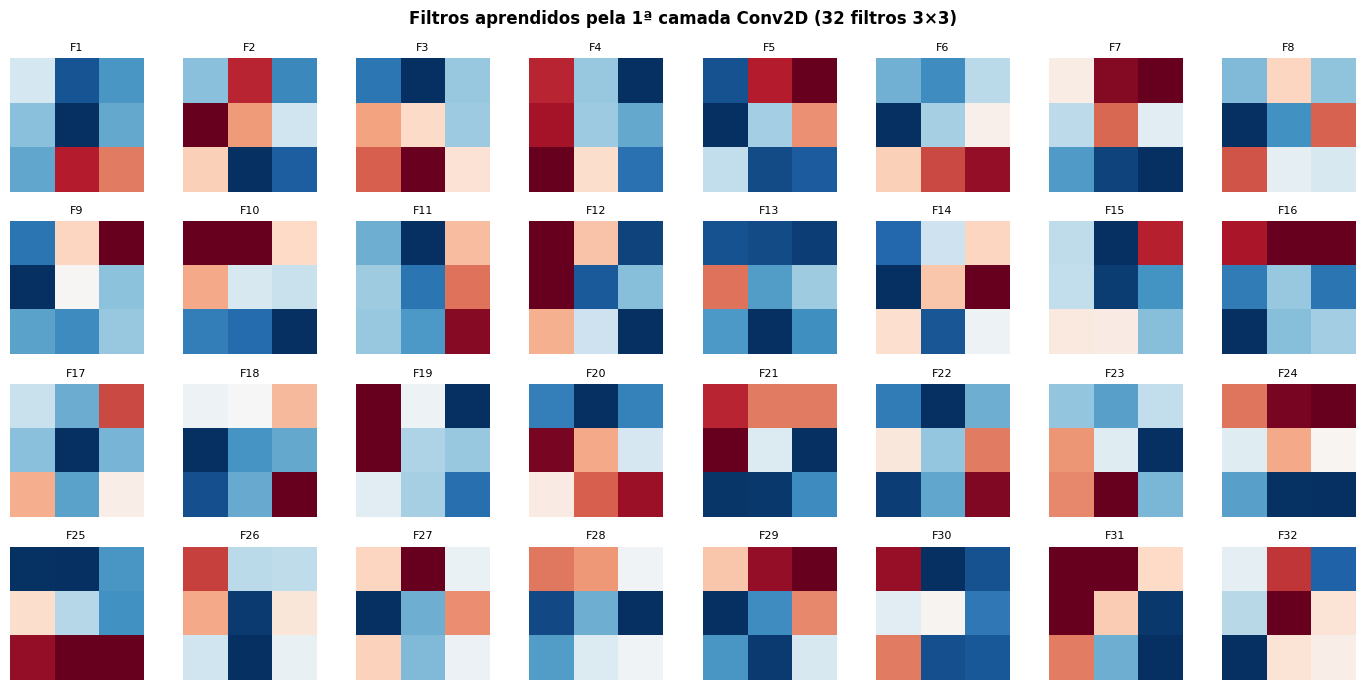

In [ ]:
# Extrai pesos da primeira camada Conv2D
pesos_conv1 = cnn.layers[0].get_weights()[0]  # shape: (3, 3, 1, 32)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Filtros aprendidos pela 1ª camada Conv2D (32 filtros 3×3)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    filtro = pesos_conv1[:, :, 0, i]
    ax.imshow(filtro, cmap='RdBu', vmin=-filtro.max(), vmax=filtro.max())
    ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9.1 Mapas de Ativação

Podemos ver como cada camada da CNN "enxerga" uma imagem, extraindo os **mapas de ativação** (feature maps).

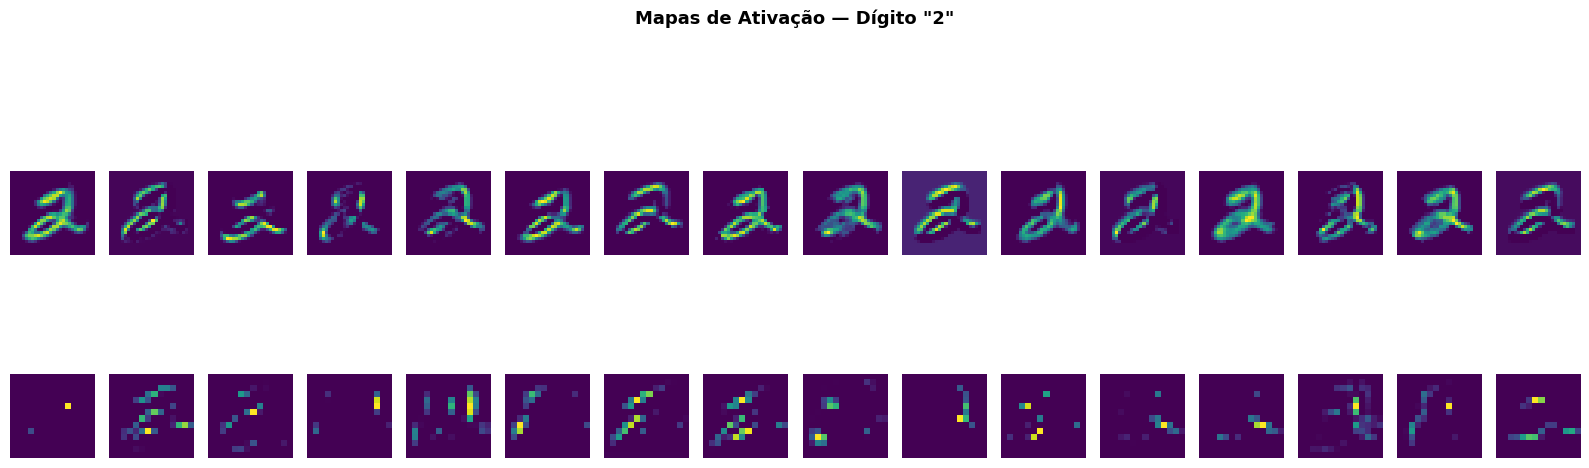

In [ ]:
# Modelo auxiliar que retorna saídas intermediárias
# Garante que o modelo CNN esteja construído, executando uma predição em um dado de exemplo.
# Isso garante que o grafo do modelo esteja totalmente construído antes de tentar
# extrair seus tensores de entrada/saída.
cnn(X_treino_cnn[:1])

modelo_ativacoes = keras.Model(
    inputs=cnn.layers[0].input,
    outputs=[layer.output for layer in cnn.layers if 'conv' in layer.name]
)

idx_exemplo = 5
img_entrada = X_treino_cnn[idx_exemplo:idx_exemplo+1]
ativacoes = modelo_ativacoes.predict(img_entrada, verbose=0)

nomes_camadas = [l.name for l in cnn.layers if 'conv' in l.name]

fig = plt.figure(figsize=(16, 6))
fig.suptitle(f'Mapas de Ativação — Dígito "{y_treino[idx_exemplo]}"', fontsize=13, fontweight='bold')

for camada_idx, (ativacao, nome) in enumerate(zip(ativacoes, nomes_camadas)):
    n_filtros = min(16, ativacao.shape[-1])
    for f in range(n_filtros):
        ax = fig.add_subplot(len(ativacoes), n_filtros, camada_idx * n_filtros + f + 1)
        ax.imshow(ativacao[0, :, :, f], cmap='viridis')
        ax.axis('off')
        if f == 0:
            ax.set_ylabel(nome, fontsize=8, rotation=0, labelpad=60)

plt.tight_layout()
plt.show()

## 10. Fazendo Previsões em Novas Imagens

Vamos testar o modelo com imagens desenhadas à mão ou enviadas pelo usuário.


--- Exemplo #250 (rótulo real: 4) ---


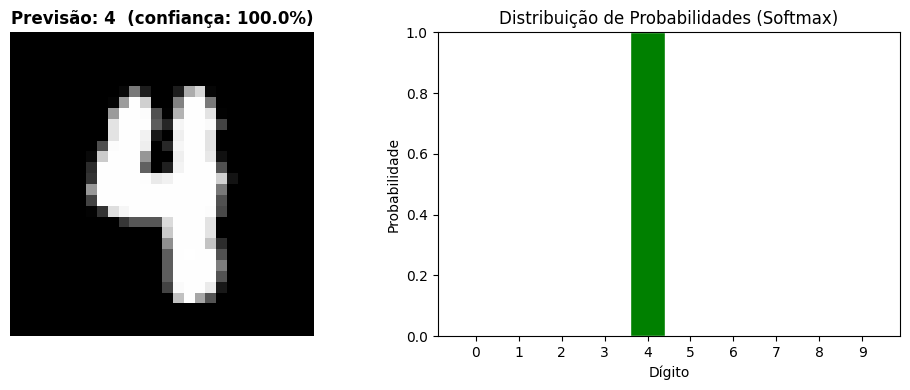


--- Exemplo #5007 (rótulo real: 6) ---


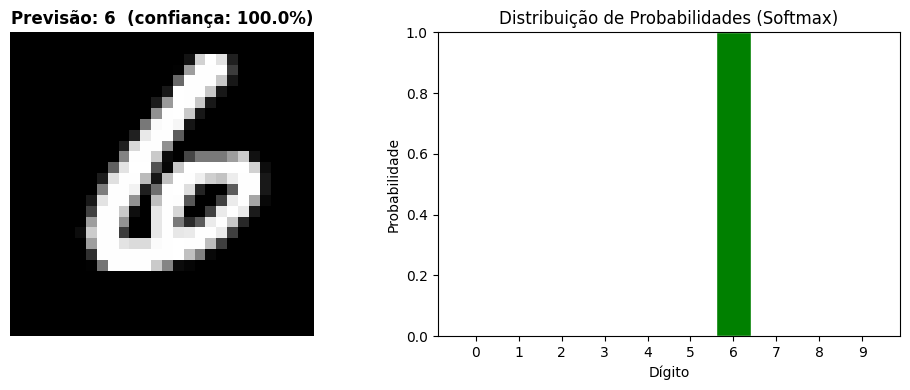


--- Exemplo #7238 (rótulo real: 7) ---


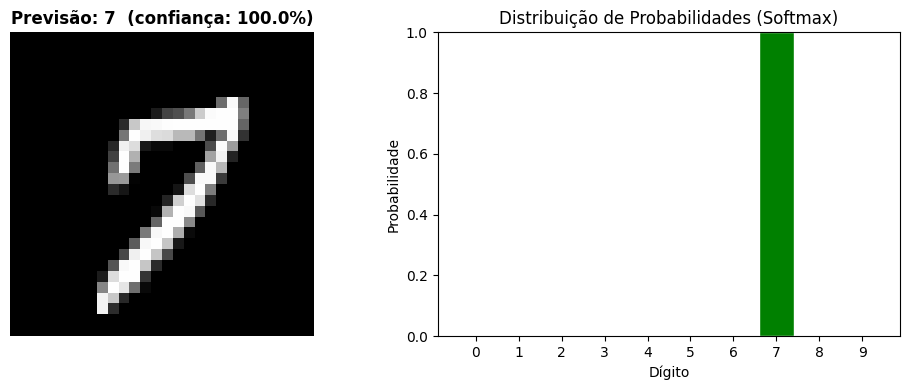

In [ ]:
def prever_digito(imagem_28x28, modelo='cnn'):
    """
    Recebe uma imagem 28×28 (valores 0–255) e retorna a previsão.
    modelo: 'cnn' ou 'mlp'
    """
    img = imagem_28x28.astype('float32') / 255.0

    if modelo == 'cnn':
        entrada = img.reshape(1, 28, 28, 1)
        m = cnn
    else:
        entrada = img.reshape(1, 784)
        m = mlp

    probs = m.predict(entrada, verbose=0)[0]
    classe = np.argmax(probs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(imagem_28x28, cmap='gray')
    ax1.set_title(f'Previsão: {classe}  (confiança: {probs[classe]*100:.1f}%)',
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    cores = ['green' if i == classe else 'steelblue' for i in range(10)]
    ax2.bar(range(10), probs, color=cores, edgecolor='white')
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Dígito'); ax2.set_ylabel('Probabilidade')
    ax2.set_title('Distribuição de Probabilidades (Softmax)')
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()
    return classe, probs

# Teste com exemplos aleatórios do conjunto de teste
for _ in range(3):
    idx = np.random.randint(0, len(X_teste))
    print(f'\n--- Exemplo #{idx} (rótulo real: {y_teste[idx]}) ---')
    prever_digito(X_teste[idx], modelo='cnn')

## 11. Exercícios Propostos

Agora é a sua vez! Tente as modificações abaixo e observe o impacto na acurácia.

---

### Exercício 1 — Impacto da Normalização
Treine a MLP **sem normalizar** os dados e compare a acurácia e a velocidade de convergência.

In [ ]:
# Exercício 1: Treine sem normalização
# DICA: use X_treino (inteiros 0-255) em vez de X_treino_flat

# Seu código aqui


### Exercício 2 — Arquitetura
Adicione uma terceira camada convolucional à CNN com 128 filtros. A acurácia melhora? O tempo de treino aumenta?

In [ ]:
# Exercício 2: CNN com 3 blocos convolucionais
def criar_cnn_profunda():
    # Seu código aqui
    pass

# cnn3 = criar_cnn_profunda()
# cnn3.summary()

### Exercício 3 — Data Augmentation
Aplique transformações aleatórias nas imagens de treino (rotação, zoom) e verifique se o modelo fica mais robusto.

In [ ]:
# Exercício 3: Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,    # rotação aleatória de até 10 graus
    zoom_range=0.1,       # zoom de até 10%
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Visualize os efeitos do augmentation
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Data Augmentation — original (cima) vs. aumentado (baixo)', fontweight='bold')

img_original = X_treino_cnn[:8]
lotes = datagen.flow(img_original, batch_size=8, shuffle=False)
img_aug = next(lotes)

for i in range(8):
    axes[0, i].imshow(img_original[i, :, :, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(img_aug[i, :, :, 0], cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Para treinar com augmentation, descomente abaixo:
# cnn_aug = criar_cnn()
# cnn_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# historico_aug = cnn_aug.fit(
#     datagen.flow(X_treino_cnn, y_treino, batch_size=128),
#     epochs=20, validation_data=(X_teste_cnn, y_teste)
# )

### Exercício 4 — Batch Normalization
Substitua o Dropout por **Batch Normalization** na CNN. O que muda no treino?

In [ ]:
# Exercício 4: CNN com Batch Normalization
def criar_cnn_batchnorm():
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),  # normaliza saídas da camada
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(10, activation='softmax'),
    ], name='CNN_BatchNorm')
    return modelo

# Seu código para treinar e avaliar aqui


## 12. Resumo e Comparação Final

Vamos consolidar o que aprendemos nesta aula.

In [ ]:
# Tabela comparativa
resultados = {
    'Modelo':      ['MLP',       'CNN'],
    'Parâmetros':  [mlp.count_params(), cnn.count_params()],
    'Acurácia':    [f'{acc_mlp*100:.2f}%', f'{acc_cnn*100:.2f}%'],
    'Épocas':      [len(historico_mlp.history['accuracy']),
                    len(historico_cnn.history['accuracy'])],
}

print('\n=== Comparação Final ===')
print(f"{'Modelo':<10} {'Parâmetros':>12} {'Acurácia':>10} {'Épocas':>8}")
print('-' * 45)
for i in range(2):
    print(f"{resultados['Modelo'][i]:<10} "
          f"{resultados['Parâmetros'][i]:>12,} "
          f"{resultados['Acurácia'][i]:>10} "
          f"{resultados['Épocas'][i]:>8}")

print('\n=== Conceitos-chave desta aula ===')
conceitos = [
    '✓ MNIST: dataset padrão para classificação de dígitos',
    '✓ Normalização: essencial para estabilizar o treinamento',
    '✓ MLP: rede densa, trata pixels independentemente',
    '✓ CNN: usa convoluções para capturar estrutura espacial',
    '✓ Dropout / Batch Norm: técnicas de regularização',
    '✓ Early Stopping: evita overfitting e economiza tempo',
    '✓ Softmax: converte logits em probabilidades',
    '✓ Matriz de Confusão: diagnóstica erros por classe',
]
for c in conceitos:
    print(c)

---

## Referências

1. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based learning applied to document recognition*. Proceedings of the IEEE.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. https://www.deeplearningbook.org
3. Documentação do TensorFlow/Keras: https://keras.io
4. Dataset MNIST: http://yann.lecun.com/exdb/mnist/

---
*Notebook criado para a disciplina de Inteligência Artificial — Ciência da Computação*